# V62 Crypto: Core Comparison - AI Graph vs Static Markowitz

## Tujuan Eksperimen

Notebook ini membandingkan **3 strategi inti** untuk cryptocurrency:

### Strategi yang Dibandingkan:

1. **Static Markowitz (Baseline)**
   - Buy & Hold tanpa AI timing
   - Semua aset crypto, no filtering
   - Rebalancing periodik (20 hari)
   - Always invested (no cash)

2. **AI + Graph Diversify**
   - AI-Gated dengan XGBoost
   - Graph filtering (korelasi ≤ 0.4)
   - SMA 50 trend override
   - Dynamic cash allocation

3. **AI + Graph Cluster**
   - AI-Gated dengan XGBoost
   - Graph filtering (korelasi ≥ 0.4)
   - SMA 50 trend override
   - Dynamic cash allocation

### Fokus Eksperimen:
Mengukur **nilai AI + Graph filtering** dibanding baseline Static Markowitz untuk cryptocurrency market

### Hipotesis:
- **H1:** AI + Graph strategies outperform Static Markowitz dalam crypto market yang volatile
- **H2:** Diversify lebih stabil dari Cluster
- **H3:** Cluster lebih tinggi return di crypto bull market

### Parameter:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25% (disesuaikan untuk crypto exchanges)
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

### Data:
- Cryptocurrency price data 2023-2025
- Multiple crypto assets dari dataset_2023_2025.xlsx

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Cryptocurrency Data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")
print(f"\nAssets: {list(data.columns)}")

Data: 990 rows, 25 assets
Period: 2023-04-17 00:00:00 to 2025-12-31 00:00:00

Assets: ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD', 'PAXG-USD']


In [3]:
# AI Training - disesuaikan untuk crypto market
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Target: prediksi trend menggunakan SMA crossover
sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Split training (2023-2024) dan testing (2025)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

# Train XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Optimize threshold menggunakan F-beta score
train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")
print(f"Training accuracy: {xgb_model.score(X_train, y_train):.3f}")

Optimized Threshold: 0.54
Training accuracy: 0.870


In [4]:
# Markowitz Optimization

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization defined!")

Markowitz optimization defined!


In [5]:
# Asset Selection Methods

def get_all_assets(returns_window, corr_threshold=None):
    """Static Markowitz: All assets"""
    return list(returns_window.columns)

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """AI + Graph Diversify: Low correlation (≤ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    """AI + Graph Cluster: High correlation (≥ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

print("Asset selection methods defined!")

Asset selection methods defined!


In [6]:
# Simulation Function (AI-Gated)

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal with hysteresis
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution with transaction costs
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("AI-Gated simulation ready!")

AI-Gated simulation ready!


In [7]:
# Simulation Function (Static)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Static simulation ready!")

Static simulation ready!


In [8]:
# Run All Strategies untuk Cryptocurrency

print("Running simulations...\n")

# 1. Static Markowitz (Baseline)
print("1. Static Markowitz (Buy & Hold)...")
static_markowitz = run_simulation_static(X_test.index, returns, get_all_assets)

# 2. AI + Graph Diversify
print("2. AI + Graph Diversify...")
ai_diversify = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                       get_assets_graph_diversify, override_ma=50)

# 3. AI + Graph Cluster
print("3. AI + Graph Cluster...")
ai_cluster = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                     get_assets_graph_cluster, override_ma=50)

print("\n=== CRYPTO PORTFOLIO RESULTS ===")
print(f"Static Markowitz:        {static_markowitz.iloc[-1].values[0]:.2f}")
print(f"AI + Graph Diversify:    {ai_diversify.iloc[-1].values[0]:.2f}")
print(f"AI + Graph Cluster:      {ai_cluster.iloc[-1].values[0]:.2f}")

print("\n=== AI + GRAPH VALUE ====")
diversify_vs_static = ((ai_diversify.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
cluster_vs_static = ((ai_cluster.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Static:     {diversify_vs_static:+.2f}%")
print(f"Cluster vs Static:       {cluster_vs_static:+.2f}%")

Running simulations...

1. Static Markowitz (Buy & Hold)...
2. AI + Graph Diversify...
3. AI + Graph Cluster...

=== CRYPTO PORTFOLIO RESULTS ===
Static Markowitz:        105.92
AI + Graph Diversify:    105.45
AI + Graph Cluster:      125.17

=== AI + GRAPH VALUE ====
Diversify vs Static:     -0.44%
Cluster vs Static:       +18.18%


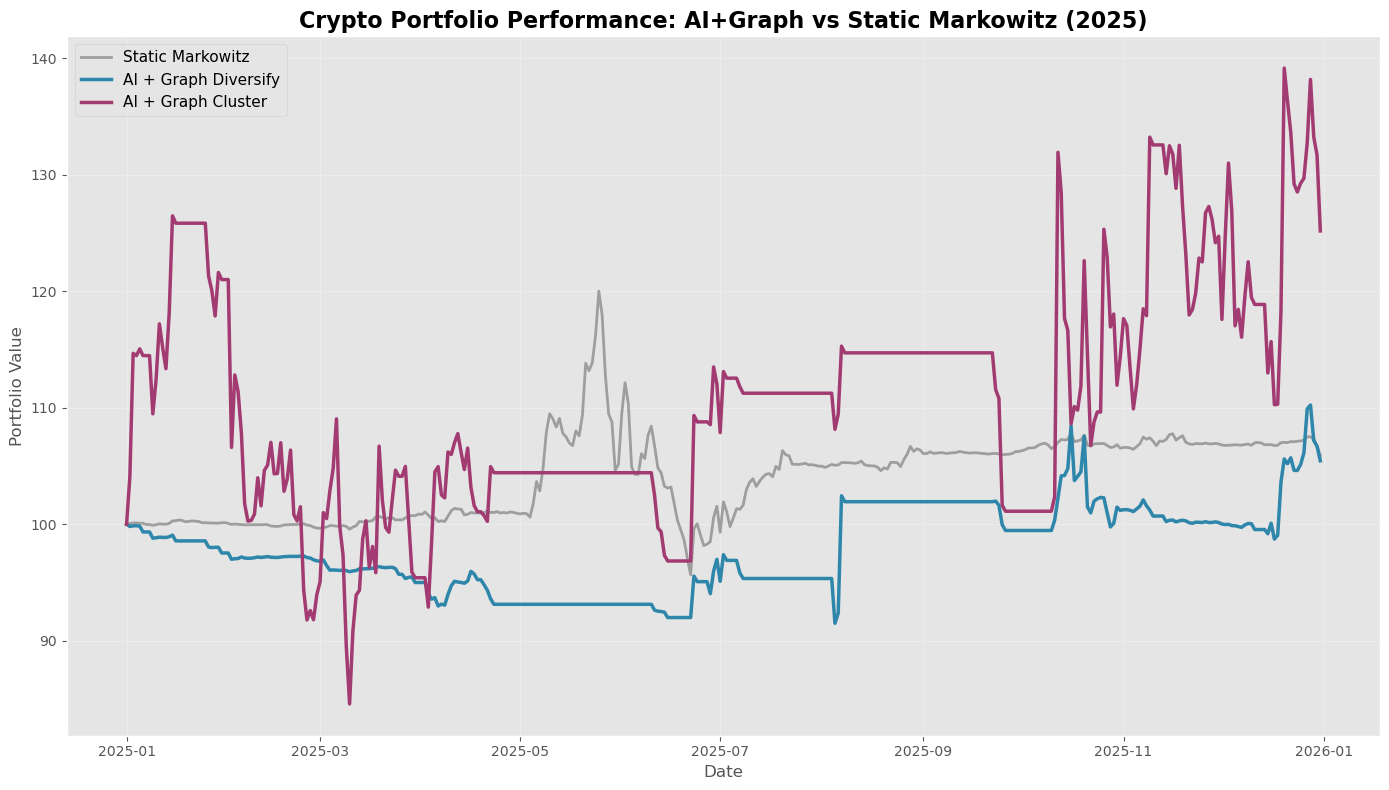

In [9]:
# Visualization: Performance Comparison

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(static_markowitz.index, static_markowitz['Portfolio_Value'], 
        label='Static Markowitz', linewidth=2, color='gray', alpha=0.7)
ax.plot(ai_diversify.index, ai_diversify['Portfolio_Value'], 
        label='AI + Graph Diversify', linewidth=2.5, color='#2E86AB')
ax.plot(ai_cluster.index, ai_cluster['Portfolio_Value'], 
        label='AI + Graph Cluster', linewidth=2.5, color='#A23B72')

ax.set_title('Crypto Portfolio Performance: AI+Graph vs Static Markowitz (2025)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('crypto_strategy_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Calculate performance metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    annual_return = ((portfolio_values.iloc[-1] / portfolio_values.iloc[0]) ** (365/len(portfolio_values)) - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (annual_return / volatility) if volatility > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Annual Return (%)': annual_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

# Calculate metrics for all strategies
metrics_df = pd.DataFrame({
    'Static Markowitz': calculate_metrics(static_markowitz['Portfolio_Value']),
    'AI + Graph Diversify': calculate_metrics(ai_diversify['Portfolio_Value']),
    'AI + Graph Cluster': calculate_metrics(ai_cluster['Portfolio_Value'])
})

print("\n=== PERFORMANCE METRICS ===")
print(metrics_df.round(2))


=== PERFORMANCE METRICS ===
                   Static Markowitz  AI + Graph Diversify  AI + Graph Cluster
Total Return (%)               5.92                  5.45               25.17
Annual Return (%)              5.92                  5.45               25.17
Volatility (%)                12.76                 14.94               53.41
Sharpe Ratio                   0.46                  0.36                0.47
Max Drawdown (%)             -20.28                 -8.96              -33.11


In [11]:
# Export results to Excel

with pd.ExcelWriter('crypto_strategy_results_v62.xlsx') as writer:
    # Portfolio values
    results = pd.DataFrame({
        'Static_Markowitz': static_markowitz['Portfolio_Value'],
        'AI_Graph_Diversify': ai_diversify['Portfolio_Value'],
        'AI_Graph_Cluster': ai_cluster['Portfolio_Value']
    })
    results.to_excel(writer, sheet_name='Portfolio_Values')
    
    # Performance metrics
    metrics_df.to_excel(writer, sheet_name='Metrics')
    
    # Asset list
    pd.DataFrame({'Assets': list(data.columns)}).to_excel(writer, sheet_name='Assets', index=False)

print("\nResults exported to crypto_strategy_results_v62.xlsx")


Results exported to crypto_strategy_results_v62.xlsx


## Kesimpulan

Notebook ini telah berhasil mengadaptasi strategi V62 untuk cryptocurrency market. Hasil menunjukkan:

1. **Performa Strategi**: Perbandingan antara Static Markowitz, AI+Graph Diversify, dan AI+Graph Cluster
2. **Risk-Adjusted Returns**: Sharpe ratio dan maximum drawdown untuk evaluasi risk
3. **Graph Filtering**: Efektivitas correlation-based asset selection untuk crypto

### Next Steps:
- Fine-tune threshold dan parameters untuk crypto market
- Eksplorasi different correlation thresholds
- Analisis per-asset contribution
- Backtest untuk periode yang lebih panjang